In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# make plots look better
sns.set_style("whitegrid")

In [102]:
df = pd.read_csv("zomato-dataset.csv")
df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [103]:
df.shape

(56252, 13)

In [104]:
df.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

In [106]:
df.describe()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
count,56235,56236,56233,56194,48414,56174,54956,56126,55914,28027,56049,55731,51642
unique,13397,11914,2639,2902,2877,5195,17712,2920,2961,8067,5553,2879,2783
top,('Rated 4.0',('Rated 4.0',Yes,No,NEW,0,('Rated 4.0',BTM,Quick Bites,('Rated 4.0',North Indian,300,Delivery
freq,942,300,30444,45268,2208,10027,412,5125,19132,407,2913,7576,24317


In [107]:
df.isnull().sum()

,0
address,17
name,16
online_order,19
book_table,58
rate,7838
votes,78
phone,1296
location,126
rest_type,338
dish_liked,28225


In [108]:
df.dropna(inplace=True)

In [109]:
df.duplicated().sum()

np.int64(4020)

In [110]:
df.drop_duplicates(inplace=True)

# Correlation Analysis

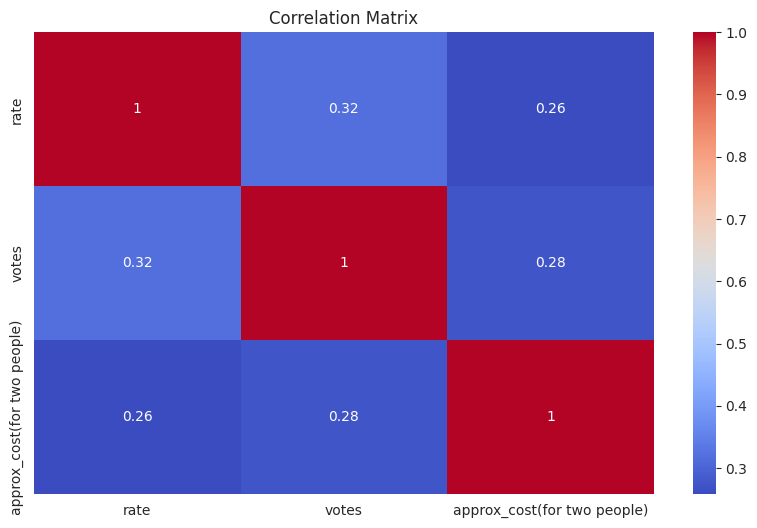

In [111]:
df['rate'] = df['rate'].astype(str).str.replace('/5', '').replace('NEW', np.nan)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '', regex=False)
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

# Drop rows where essential numerical columns became NaN after cleaning
df.dropna(subset=['rate', 'votes', 'approx_cost(for two people)'], inplace=True)

numerical_df = df.select_dtypes(include=['int64','float64'])

corr = numerical_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

# Distribution of Online Orders

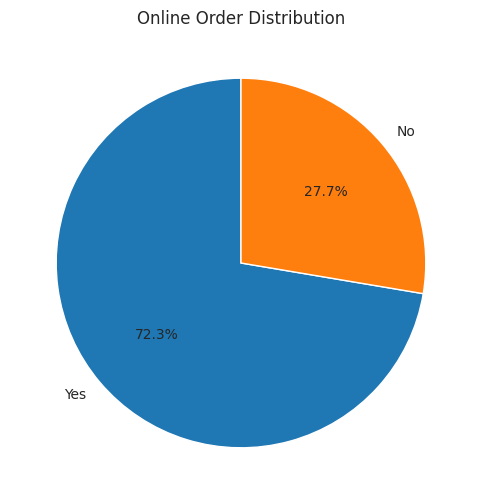

In [112]:
online_counts = df['online_order'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(online_counts,
        labels=online_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Online Order Distribution")
plt.show()

# Restaurant Type Distribution

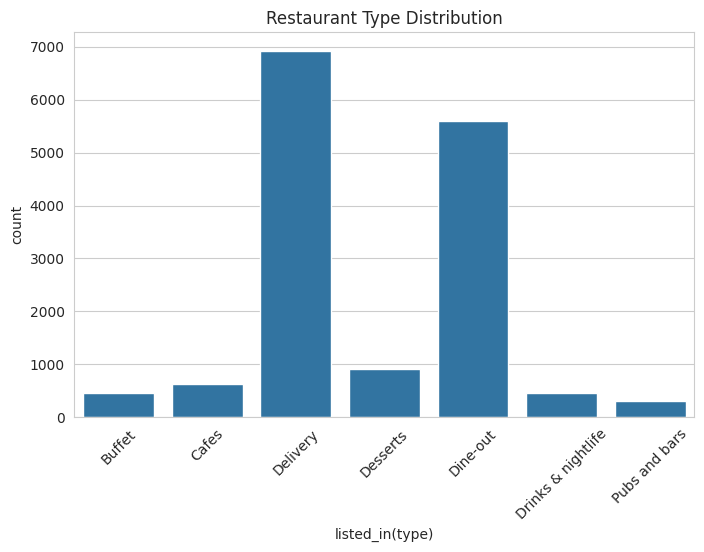

In [113]:
plt.figure(figsize=(8,5))

sns.countplot(x='listed_in(type)', data=df)

plt.xticks(rotation=45)
plt.title("Restaurant Type Distribution")

plt.show()

# Rating Distribution

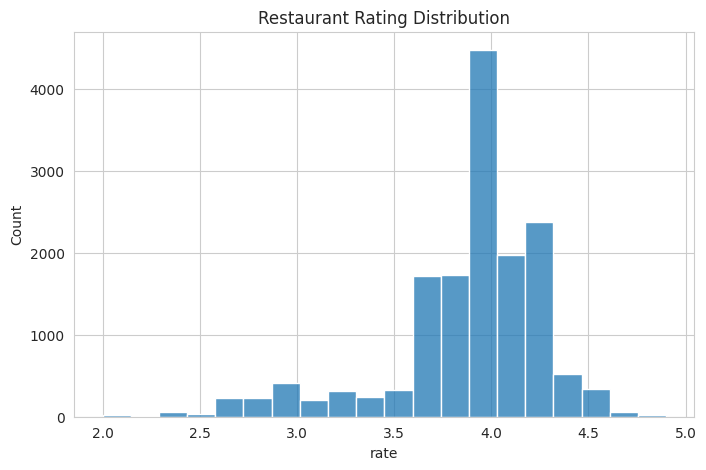

In [114]:
plt.figure(figsize=(8,5))

sns.histplot(df['rate'], bins=20)

plt.title("Restaurant Rating Distribution")

plt.show()

# Cost Distribution

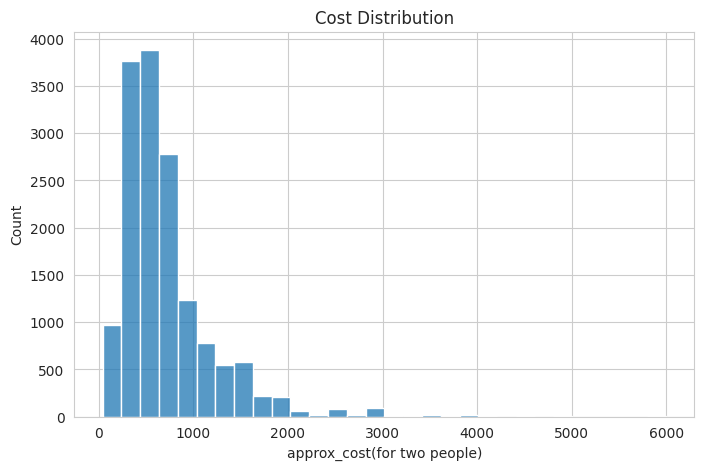

In [115]:
plt.figure(figsize=(8,5))

sns.histplot(df['approx_cost(for two people)'], bins=30)

plt.title("Cost Distribution")

plt.show()

# Top 10 Locations

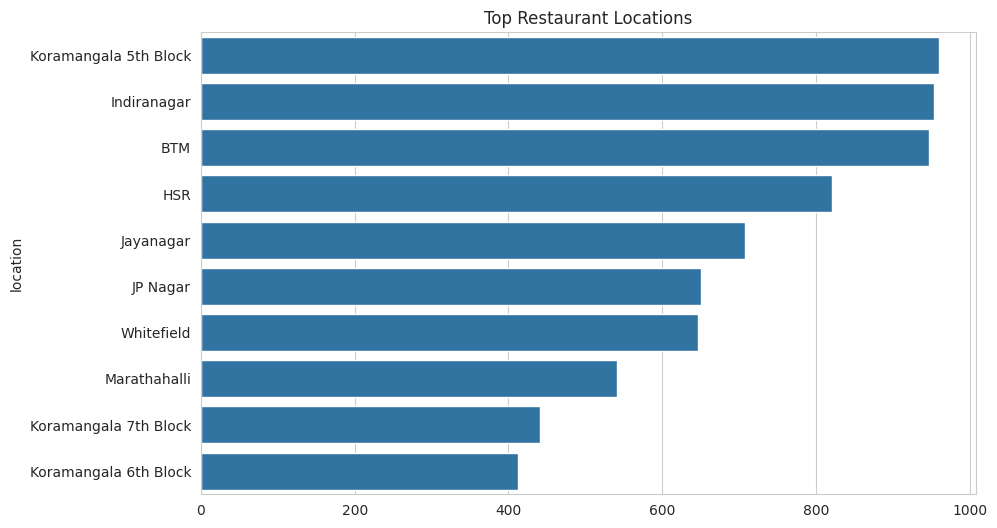

In [116]:
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_locations.values,
            y=top_locations.index)

plt.title("Top Restaurant Locations")

plt.show()

# Rating vs Online Order

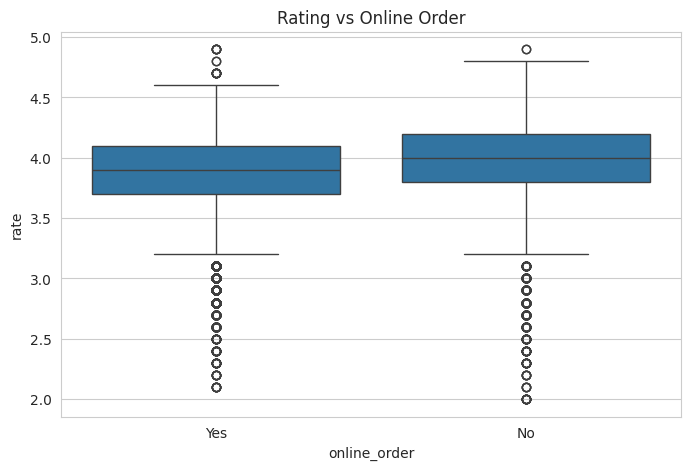

In [117]:
plt.figure(figsize=(8,5))

sns.boxplot(x='online_order', y='rate', data=df)

plt.title("Rating vs Online Order")
plt.show()

# Rating vs Table Booking

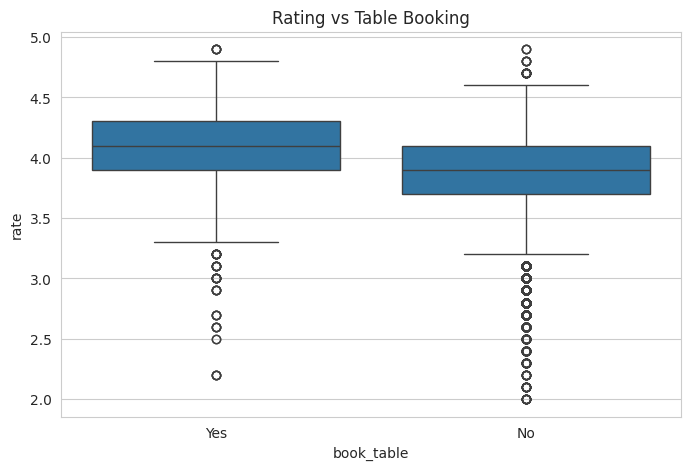

In [118]:
plt.figure(figsize=(8,5))

sns.boxplot(x='book_table', y='rate', data=df)

plt.title("Rating vs Table Booking")
plt.show()

# Votes vs Rating

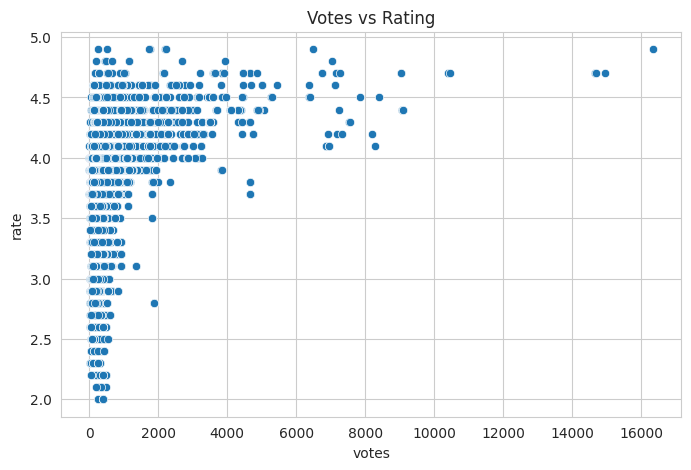

In [119]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='votes', y='rate', data=df)

plt.title("Votes vs Rating")
plt.show()

# Cuisine vs Rating Analysis

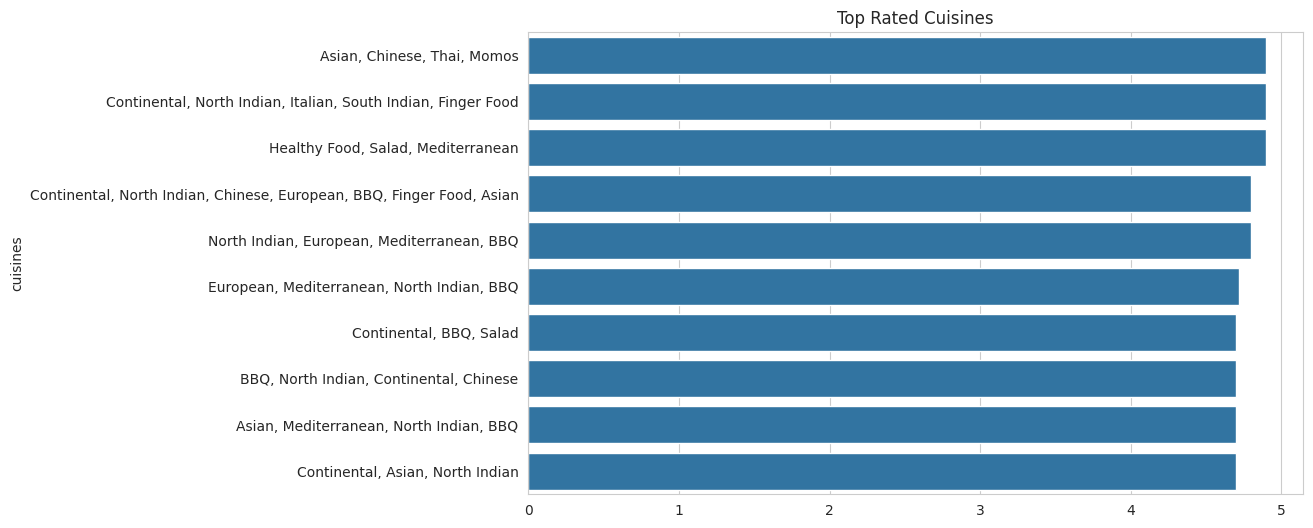

In [120]:
cuisine_rating = df.groupby('cuisines')['rate'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=cuisine_rating.values,
            y=cuisine_rating.index)

plt.title("Top Rated Cuisines")

plt.show()

# Location Hotspots

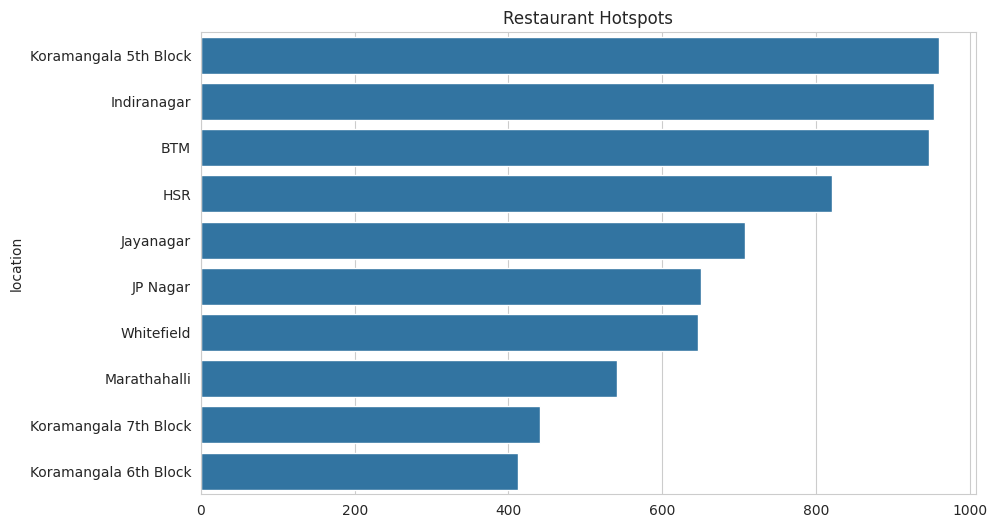

In [121]:
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_locations.values,
            y=top_locations.index)

plt.title("Restaurant Hotspots")

plt.show()

# Price vs Rating Relationship

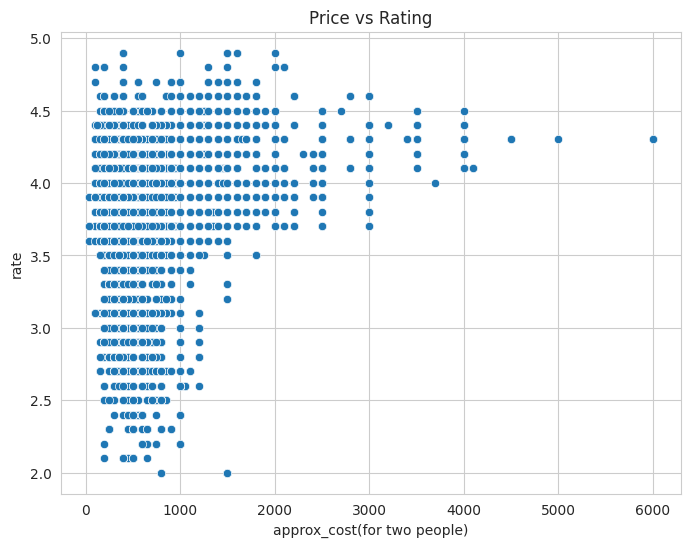

In [122]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='approx_cost(for two people)',
    y='rate',
    data=df
)

plt.title("Price vs Rating")

plt.show()

# Rating between 3.5 to 4.5

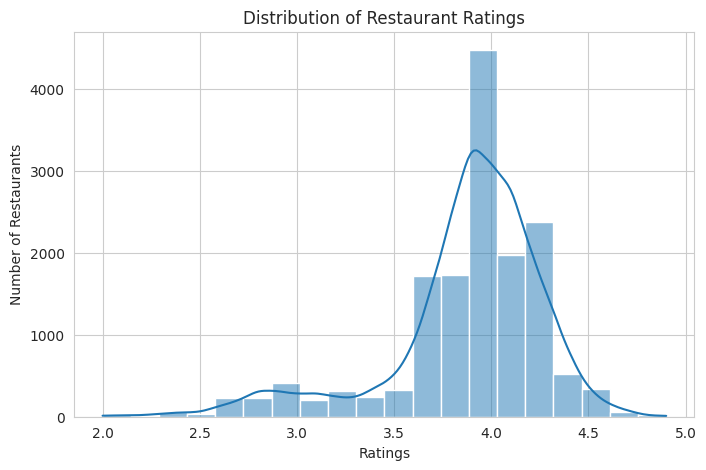

In [123]:
plt.figure(figsize=(8,5))

sns.histplot(df['rate'], bins=20, kde=True)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Ratings")
plt.ylabel("Number of Restaurants")

plt.show()

# Scikit-Learn

In [124]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['rate','name','address','phone','dish_liked'])
y = df['rate']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [125]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [126]:
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(exclude='object').columns

In [127]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

In [128]:
encoder = OneHotEncoder(drop='first', handle_unknown='ignore')

In [129]:
transformer = ColumnTransformer(
    transformers=[
        ('num', num_imputer, numerical_cols),
        ('cat', encoder, categorical_cols)
    ],
    remainder='passthrough'
)

In [130]:
X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [98]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train_transformed, y_train)

RandomForestRegressor()

In [99]:
y_pred = model.predict(X_test_transformed)

In [100]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 0.02104389470738983
R2 Score: 0.8669623886082232
